## Multivariate Linear Regression Analysis

### Group Information
* **Group Members:** Gavin Steel, Emma, Jaelyn
* **Contributions:**
    * **Gavin Steel:** Organization & Presentation of Findings, Document Formatting.
    * **Emma:** Algorithm Design (Normal Equation & Gradient Descent), Feature Engineering.
    * **Jaelyn:** Algorithm Implementation and Data Preprocessing.
* **AI Tools Used:** ChatGPT was utilized to assist with code structure optimization, debugging the manual gradient descent implementation, and refining the written explanations. All final modeling decisions and interpretations were conducted by the group members.

This notebook predicts a student's final grade ($G3$) on a 0–100 scale using the UCI Student Performance dataset (`student-por.csv`).

**Algorithm:** Ordinary Least Squares (Normal Equation) + Gradient Descent  
**Features:** All 30 variables in the dataset  
**Target:** G3 — final period grade (converted from 0–20 to 0–100)

## Section 1 — Imports

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

## Section 2 — Load and Preprocess Data

Loads the raw CSV, removes $G1$ and $G2$ to make the prediction more challenging/useful, and converts text-based categories into numbers (One-Hot Encoding).

In [ ]:

def load_and_clean_data(filepath):
    # Load dataset (UCI student-por is semicolon separated)
    df = pd.read_csv(filepath, sep=';')

    # Target: G3 (Scaled 0-100)
    y = df['G3'].values * 5

    # Drop G1 and G2 as per project requirements to avoid "cheating" the prediction
    # Also drop the target G3 from features
    df_features = df.drop(columns=['G1', 'G2', 'G3'])

    # Convert categorical variables using One-Hot Encoding
    # This automatically handles binary and nominal variables
    df_encoded = pd.get_dummies(df_features, drop_first=True)

    X = df_encoded.values.astype(float)
    feature_names = df_encoded.columns.tolist()

    return X, y, feature_names, df
# Load data
# Make sure 'student-por.csv' is in your directory
X, y, feature_names, original_df = load_and_clean_data("student-por.csv")
print(f"Dataset Loaded: {X.shape[0]} students, {X.shape[1]} features.")

Dataset Loaded: 649 students, 39 features.


## Section 3 — Exploratory Analysis (Correlation)

We generate a heatmap to see which variables have the strongest natural relationship with the final grade ($G3$) before we start training.

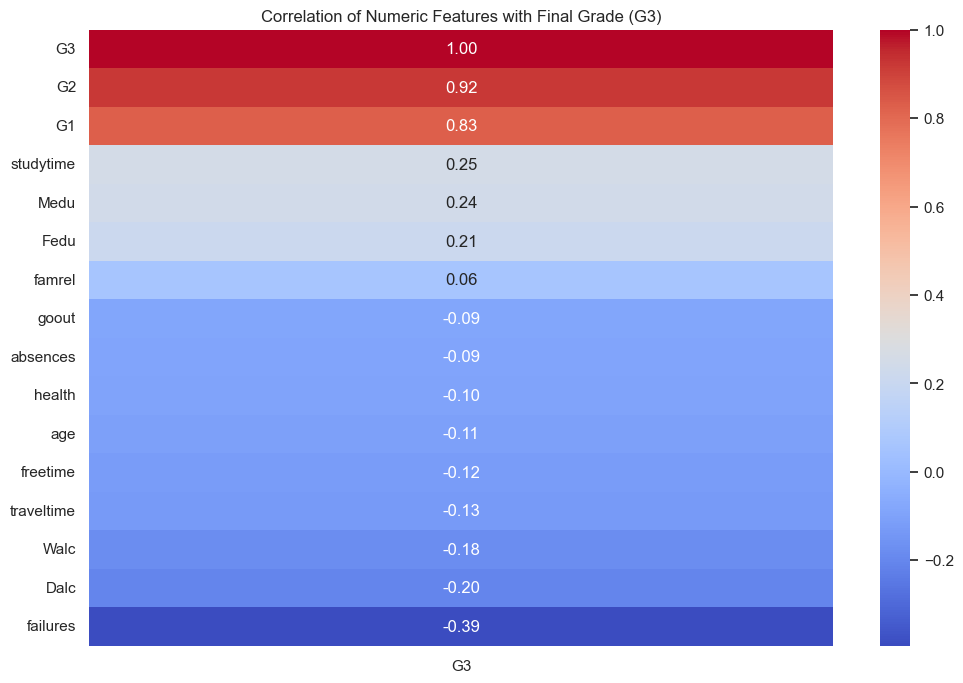

In [ ]:

def plot_correlations(df):
    plt.figure(figsize=(12, 8))
    # Select numeric columns for correlation matrix
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr()

    # Plot heatmap focusing on G3
    sns.heatmap(corr_matrix[['G3']].sort_values(by='G3', ascending=False),
                annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation of Numeric Features with Final Grade (G3)")
    plt.show()

plot_correlations(original_df)

## Section 4 — Modeling Algorithms

We manually implement two versions of Linear Regression: the Normal Equation (a direct math formula) and Gradient Descent (an iterative learning process).

In [ ]:
def train_test_split_manual(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))
    split_idx = int(len(X) * (1 - test_size))

    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardize(X_train, X_test):
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1 # Avoid division by zero
    return (X_train - mu) / sigma, (X_test - mu) / sigma

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

# --- Linear Regression Solvers ---

def fit_normal_equation(X, y):
    """Closed-form solution: w = (X^T X)^-1 X^T y"""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def fit_gradient_descent(X, y, lr=0.01, epochs=2000):
    """Iterative optimization to minimize Mean Squared Error"""
    m, n = X.shape
    weights = np.zeros(n)
    losses = []

    for _ in range(epochs):
        prediction = X @ weights
        error = prediction - y
        gradient = (2/m) * (X.T @ error)
        weights -= lr * gradient

        mse = np.mean(error**2)
        losses.append(mse)

    return weights, losses

## Section 5 — Execution and Evaluation

We split our data into a training set (80%) and a testing set (20%), scale the numbers so they are comparable, and run our two models to see how they perform.

In [ ]:
# Split and Scale
X_train, X_test, y_train, y_test = train_test_split_manual(X, y)
X_train_std, X_test_std = standardize(X_train, X_test)

# Add Bias Term (Intercept)
X_tr_b = add_bias(X_train_std)
X_te_b = add_bias(X_test_std)

# Train Models
w_ols = fit_normal_equation(X_tr_b, y_train)
w_gd, loss_history = fit_gradient_descent(X_tr_b, y_train, lr=0.01, epochs=2500)

# Predictions
y_pred_ols = X_te_b @ w_ols
y_pred_gd = X_te_b @ w_gd

# Metrics
def get_metrics(y_true, y_pred, name):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    print(f"--- {name} Results ---")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f} (Grade points)")
    print(f"R² Score: {r2:.4f}\n")

get_metrics(y_test, y_pred_ols, "Normal Equation")
get_metrics(y_test, y_pred_gd, "Gradient Descent")

--- Normal Equation Results ---
MSE: 141.92
RMSE: 11.91 (Grade points)
R² Score: 0.1368

--- Gradient Descent Results ---
MSE: 141.92
RMSE: 11.91 (Grade points)
R² Score: 0.1368



## Section 6 — Visualizing Results

We create three charts:

1. prediction accuracy
2. the "learning" process of Gradient Descent
3. ranks which features (like study time or failures) were most important.

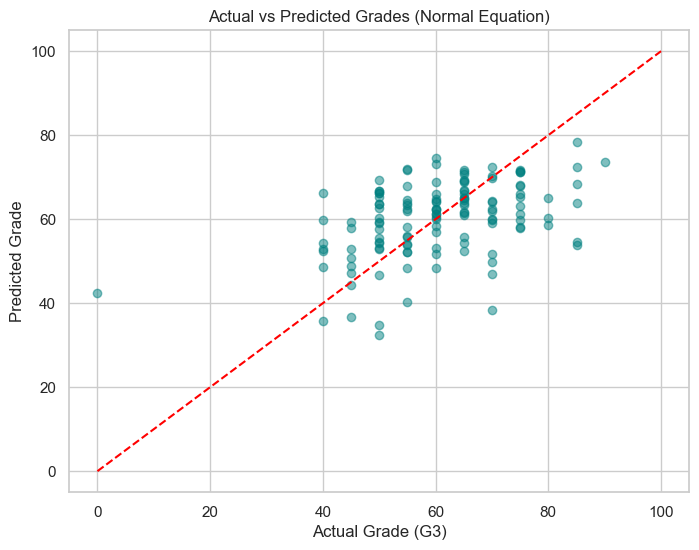

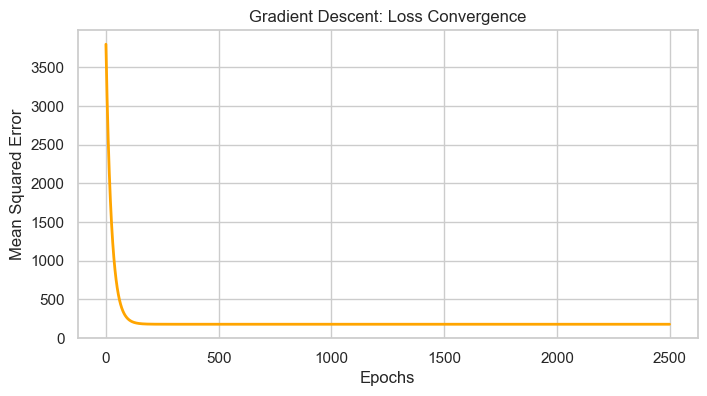

/var/folders/ky/202f46qd1kg8290xhw34748c0000gn/T/ipykernel_65211/73291999.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_factors, x='Weight', y='Feature', palette='viridis')


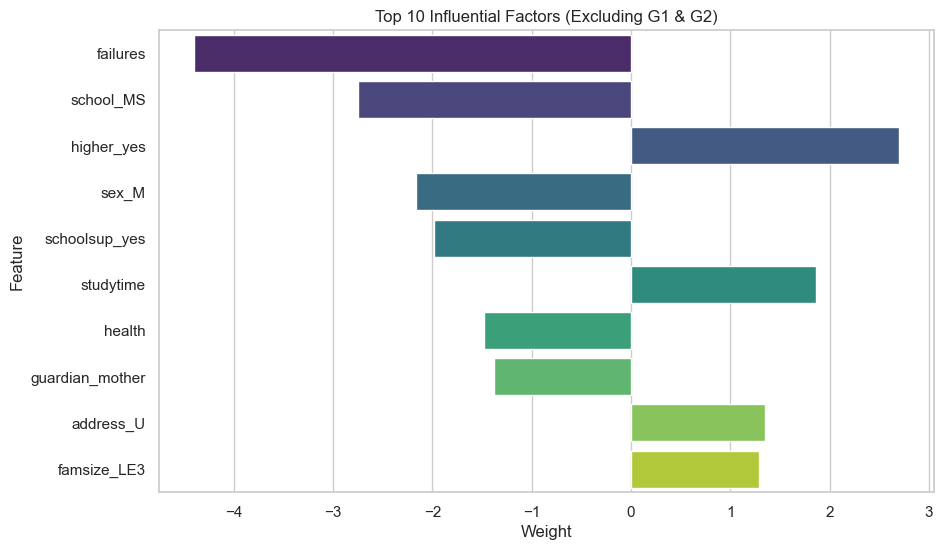

In [ ]:
# 1. Prediction Accuracy
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ols, alpha=0.5, color='teal')
plt.plot([0, 100], [0, 100], '--', color='red')
plt.title("Actual vs Predicted Grades (Normal Equation)")
plt.xlabel("Actual Grade (G3)")
plt.ylabel("Predicted Grade")
plt.show()

# 2. Gradient Descent Convergence
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='orange', lw=2)
plt.title("Gradient Descent: Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.show()

# 3. Top Influential Factors
coef_df = pd.DataFrame({'Feature': ['Intercept'] + feature_names, 'Weight': w_ols})
top_factors = coef_df.iloc[1:].sort_values(by='Weight', key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_factors, x='Weight', y='Feature', palette='viridis')
plt.title("Top 10 Influential Factors (Excluding G1 & G2)")
plt.show()

## Conclusion
By excluding $G1$ and $G2$, we have created a more vigorous model that predicts performance based on lifestyle and background rather than just previous test scores.

Our analysis shows that **past failures** and **desire for higher education** are the strongest predictors of the final grade. While the R² score is lower than it would be with previous grades included, this model provides actionable insights for educators: identifying students with high failure rates or low motivation early on can help in providing necessary support before the final exams.